# NeuroGS-Codec: Topology-aware Rate–Distortion 3D Gaussian Volume Codec (Starter Notebook)

**Purpose:** End-to-end, ready-to-run baseline for compressing a **3D microscopy volume** (voxel intensities) using an anisotropic 3D Gaussian mixture with:
- neurite-biased **structure weighting** (tubularity proxy)
- **rate–distortion** training with quantization-in-the-loop (STE)
- optional **densify/prune** hooks (microscopy-aware)

**Created:** 2026-02-03 09:14:53

> This notebook is a clean research scaffold. It prioritizes clarity over maximum speed.


## 0) Setup

In [1]:
!pip install tifffile

In [2]:

# If running in Colab, uncomment:
# !pip -q install tifffile scipy tqdm

import os
import math
import time
from dataclasses import dataclass
from typing import Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import tifffile as tiff
except ImportError as e:
    raise ImportError("Please install tifffile: pip install tifffile") from e

from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_float32_matmul_precision("high")
print("Device:", DEVICE)


Device: cuda


/venv/neurogs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load a 3D volume (.tif stack)

In [3]:

# ---- User config ----
TIF_PATH = "./10-2900-control-cell-05_cropped_corrected.tif"   # <-- set this
# Example anisotropic spacing (microns). Replace with your microscope metadata.
VOXEL_SPACING = (0.126, 0.126, 1.0)  # (dx, dy, dz)
# ---------------------

assert os.path.exists(TIF_PATH), f"File not found: {TIF_PATH}"

V_np = tiff.imread(TIF_PATH)  # expected shape: (Z, Y, X)
assert V_np.ndim == 3, f"Expected 3D volume, got shape {V_np.shape}"

print("Loaded:", V_np.shape, V_np.dtype, "min/max:", float(V_np.min()), float(V_np.max()))

# Normalize to [0,1] float32
V = V_np.astype(np.float32)
V = (V - V.min()) / (V.max() - V.min() + 1e-8)
V_t = torch.from_numpy(V).to(DEVICE)  # (Z,Y,X)


Loaded: (100, 647, 813) uint8 min/max: 2.0 255.0


## 2) Build physical coordinate grid (anisotropy-aware)

In [4]:

def make_coord_grid_zyx(shape_zyx: Tuple[int,int,int], spacing_xyz: Tuple[float,float,float], device: str):
    # Returns normalized physical coordinates in [-1,1]^3 for each voxel index.
    # shape_zyx: (Z,Y,X), spacing_xyz: (dx,dy,dz)
    Z, Y, X = shape_zyx
    dx, dy, dz = spacing_xyz

    xs = torch.arange(X, device=device) * dx
    ys = torch.arange(Y, device=device) * dy
    zs = torch.arange(Z, device=device) * dz

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    z0, z1 = zs.min(), zs.max()

    xn = (xs - x0) / (x1 - x0 + 1e-8) * 2 - 1
    yn = (ys - y0) / (y1 - y0 + 1e-8) * 2 - 1
    zn = (zs - z0) / (z1 - z0 + 1e-8) * 2 - 1

    zz, yy, xx = torch.meshgrid(zn, yn, xn, indexing="ij")
    coords = torch.stack([xx, yy, zz], dim=-1)  # (Z,Y,X,3) in (x,y,z)
    return coords

coords_grid = make_coord_grid_zyx(V_t.shape, VOXEL_SPACING, DEVICE)
print("coords_grid:", coords_grid.shape, coords_grid.dtype)


coords_grid: torch.Size([100, 647, 813, 3]) torch.float32


## 3) Neurite-likelihood map M(x): simple tubularity proxy
Label-free prior derived from the volume (DoG + gradient magnitude).

In [5]:

def gaussian_blur_3d(vol: torch.Tensor, sigma: float) -> torch.Tensor:
    # Separable 3D Gaussian blur using 1D kernels and conv3d.
    if sigma <= 0:
        return vol
    radius = int(3 * sigma + 0.5)
    x = torch.arange(-radius, radius+1, device=vol.device, dtype=vol.dtype)
    k = torch.exp(-(x**2)/(2*sigma**2))
    k = k / (k.sum() + 1e-8)

    v = vol.unsqueeze(0).unsqueeze(0)  # (1,1,Z,Y,X)

    kx = k.view(1,1,1,1,-1)
    v = F.conv3d(v, kx, padding=(0,0,radius))

    ky = k.view(1,1,1,-1,1)
    v = F.conv3d(v, ky, padding=(0,radius,0))

    kz = k.view(1,1,-1,1,1)
    v = F.conv3d(v, kz, padding=(radius,0,0))

    return v[0,0]

@torch.no_grad()
def make_neurite_map(vol_zyx: torch.Tensor) -> torch.Tensor:
    v1 = gaussian_blur_3d(vol_zyx, sigma=0.8)
    v2 = gaussian_blur_3d(vol_zyx, sigma=2.0)
    dog = (v1 - v2).abs()

    dz = F.pad(vol_zyx[1:] - vol_zyx[:-1], (0,0,0,0,0,1))
    dy = F.pad(vol_zyx[:,1:] - vol_zyx[:,:-1], (0,0,0,1,0,0))
    dx = F.pad(vol_zyx[:,:,1:] - vol_zyx[:,:,:-1], (0,1,0,0,0,0))
    gmag = torch.sqrt(dx*dx + dy*dy + dz*dz + 1e-8)

    m = dog + 0.5 * gmag
    m = (m - m.min()) / (m.max() - m.min() + 1e-8)
    return m.clamp(0,1)

M = make_neurite_map(V_t)
print("M:", M.shape, "min/max:", float(M.min()), float(M.max()), "mean:", float(M.mean()))


M: torch.Size([100, 647, 813]) min/max: 0.0 1.0 mean: 0.034591998904943466


## 4) Sampling strategy (uniform + neurite-biased)

In [6]:

@torch.no_grad()
def sample_points(coords_grid: torch.Tensor, V: torch.Tensor, M: torch.Tensor,
                  n_uniform: int, n_biased: int):
    Z,Y,X,_ = coords_grid.shape
    total = Z*Y*X

    idx_u = torch.randint(0, total, (n_uniform,), device=V.device)
    zu = idx_u // (Y*X)
    yu = (idx_u % (Y*X)) // X
    xu = idx_u % X

    # Handle large tensors: torch.multinomial has a 2^24 category limit
    flatM = M.reshape(-1)
    max_categories = 2**24 - 1
    if total > max_categories:
        # Pre-sample candidate indices, then use multinomial on the subset
        candidate_idx = torch.randint(0, total, (max_categories,), device=V.device)
        candidate_probs = flatM[candidate_idx]
        candidate_probs = candidate_probs / (candidate_probs.sum() + 1e-8)
        selected = torch.multinomial(candidate_probs, n_biased, replacement=True)
        idx_b = candidate_idx[selected]
    else:
        probs = flatM / (flatM.sum() + 1e-8)
        idx_b = torch.multinomial(probs, n_biased, replacement=True)
    
    zb = idx_b // (Y*X)
    yb = (idx_b % (Y*X)) // X
    xb = idx_b % X

    z = torch.cat([zu, zb], dim=0)
    y = torch.cat([yu, yb], dim=0)
    x = torch.cat([xu, xb], dim=0)

    pts = coords_grid[z,y,x]     # (N,3)
    tgt = V[z,y,x]               # (N,)
    mval = M[z,y,x]              # (N,)
    return pts, tgt, mval

pts, tgt, mval = sample_points(coords_grid, V_t, M, 1024, 1024)
print("Sampled:", pts.shape, tgt.shape, "m mean:", float(mval.mean()))

Sampled: torch.Size([2048, 3]) torch.Size([2048]) m mean: 0.05120161175727844


## 5) Gaussian mixture model (anisotropic, rotation via quaternion)

In [7]:

def quat_to_rotmat(q: torch.Tensor) -> torch.Tensor:
    # q: (...,4) in (w,x,y,z), assumed normalized
    w,x,y,z = q.unbind(-1)
    ww,xx,yy,zz = w*w, x*x, y*y, z*z
    wx,wy,wz = w*x, w*y, w*z
    xy,xz,yz = x*y, x*z, y*z

    R = torch.stack([
        ww+xx-yy-zz, 2*(xy-wz),     2*(xz+wy),
        2*(xy+wz),   ww-xx+yy-zz,   2*(yz-wx),
        2*(xz-wy),   2*(yz+wx),     ww-xx-yy+zz
    ], dim=-1).reshape(q.shape[:-1]+(3,3))
    return R

def safe_normalize(q: torch.Tensor, eps=1e-8) -> torch.Tensor:
    return q / (q.norm(dim=-1, keepdim=True) + eps)

class GaussianMixtureVolume(nn.Module):
    """
    Gaussian Mixture Volume with tile-based bounding box culling.
    Only evaluates Gaussians within range of query points to save memory.
    """
    def __init__(self, N: int, init_means: torch.Tensor, init_amp: torch.Tensor):
        super().__init__()
        assert init_means.shape == (N,3)
        assert init_amp.shape == (N,)
        self.N = N

        self.mu = nn.Parameter(init_means.clone())
        self.log_s = nn.Parameter(torch.zeros(N,3, device=init_means.device) - 2.0)

        q = torch.zeros(N,4, device=init_means.device)
        q[:,0] = 1.0
        self.q = nn.Parameter(q)

        self.a = nn.Parameter(init_amp.clone())
        self.b = nn.Parameter(torch.tensor(0.0, device=init_means.device))
        
        # Culling parameters
        self.sigma_cutoff = 3.0  # Number of sigmas for bounding box (3σ = 99.7% of Gaussian mass)

    def get_gaussian_bounds(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute axis-aligned bounding box for each Gaussian.
        Returns (min_bounds, max_bounds) each of shape (N, 3).
        """
        s = torch.exp(self.log_s).clamp(1e-4, 10.0)  # (N, 3)
        # For rotated Gaussians, use the max scale as conservative radius
        # (exact AABB would require rotating the ellipsoid, this is faster)
        max_radius = s.max(dim=-1, keepdim=True).values * self.sigma_cutoff  # (N, 1)
        radius_3d = max_radius.expand(-1, 3)  # (N, 3)
        
        min_bounds = self.mu - radius_3d  # (N, 3)
        max_bounds = self.mu + radius_3d  # (N, 3)
        return min_bounds, max_bounds

    def forward(self, x: torch.Tensor, use_culling: bool = True, max_gaussians_per_tile: int = 50000) -> torch.Tensor:
        """
        Forward pass with optional tile-based bounding box culling.
        
        Args:
            x: Query points (P, 3)
            use_culling: Whether to use bounding box culling (default True)
            max_gaussians_per_tile: Max Gaussians to process per tile before falling back to dense
        
        Returns:
            pred: Predicted values (P,)
        """
        P = x.shape[0]
        
        if not use_culling or self.N <= max_gaussians_per_tile:
            # Original dense computation for small N
            return self._forward_dense(x)
        
        # Tile-based culling: find Gaussians that overlap with query bounding box
        x_min = x.min(dim=0).values  # (3,)
        x_max = x.max(dim=0).values  # (3,)
        
        # Get Gaussian bounding boxes
        g_min, g_max = self.get_gaussian_bounds()  # (N, 3) each
        
        # Check overlap: Gaussian overlaps tile if g_max >= x_min AND g_min <= x_max (for all dims)
        overlaps = (g_max >= x_min.unsqueeze(0)) & (g_min <= x_max.unsqueeze(0))  # (N, 3)
        mask = overlaps.all(dim=-1)  # (N,) - True if Gaussian overlaps tile
        
        n_active = mask.sum().item()
        
        if n_active == 0:
            # No Gaussians in range, return bias only
            return torch.full((P,), self.b.item(), device=x.device, dtype=x.dtype)
        
        if n_active > max_gaussians_per_tile:
            # Too many Gaussians even after culling, fall back to dense but warn
            return self._forward_dense(x)
        
        # Extract active Gaussians
        active_idx = mask.nonzero(as_tuple=True)[0]  # (n_active,)
        mu_active = self.mu[active_idx]              # (n_active, 3)
        log_s_active = self.log_s[active_idx]        # (n_active, 3)
        q_active = self.q[active_idx]                # (n_active, 4)
        a_active = self.a[active_idx]                # (n_active,)
        
        # Compute Gaussian contributions for active subset
        dx = x[:, None, :] - mu_active[None, :, :]   # (P, n_active, 3)
        
        s = torch.exp(log_s_active).clamp(1e-4, 10.0)  # (n_active, 3)
        qn = safe_normalize(q_active)
        R = quat_to_rotmat(qn)                         # (n_active, 3, 3)
        Rt = R.transpose(-1, -2)
        
        y = torch.einsum("pni,nij->pnj", dx, Rt)       # (P, n_active, 3)
        y = y / (s[None, :, :] + 1e-8)
        exp_term = -0.5 * (y * y).sum(dim=-1)          # (P, n_active)
        g = torch.exp(exp_term)                        # (P, n_active)
        
        pred = (g * a_active[None, :]).sum(dim=1) + self.b
        return pred

    def _forward_dense(self, x: torch.Tensor) -> torch.Tensor:
        """Original dense forward pass (no culling)."""
        mu = self.mu[None, :, :]                 # (1,N,3)
        dx = x[:,None,:] - mu                    # (P,N,3)

        s = torch.exp(self.log_s).clamp(1e-4, 10.0)  # (N,3)
        qn = safe_normalize(self.q)
        R = quat_to_rotmat(qn)                   # (N,3,3)
        Rt = R.transpose(-1,-2)

        y = torch.einsum("pni,nij->pnj", dx, Rt) # (P,N,3)
        y = y / (s[None,:,:] + 1e-8)
        exp_term = -0.5 * (y*y).sum(dim=-1)      # (P,N)
        g = torch.exp(exp_term)                  # (P,N)

        pred = (g * self.a[None,:]).sum(dim=1) + self.b
        return pred
    
    def forward_tiled(self, x: torch.Tensor, tile_size: int = 1000, max_gaussians_per_tile: int = 30000) -> torch.Tensor:
        """
        Forward pass with spatial tiling for very large Gaussian counts.
        Splits query points into tiles and processes each with culling.
        
        Args:
            x: Query points (P, 3)
            tile_size: Number of query points per tile
            max_gaussians_per_tile: Max active Gaussians per tile
        
        Returns:
            pred: Predicted values (P,)
        """
        P = x.shape[0]
        
        if P <= tile_size and self.N <= max_gaussians_per_tile:
            return self.forward(x, use_culling=True, max_gaussians_per_tile=max_gaussians_per_tile)
        
        # Process in tiles
        pred = torch.empty(P, device=x.device, dtype=x.dtype)
        
        for start in range(0, P, tile_size):
            end = min(start + tile_size, P)
            x_tile = x[start:end]
            pred[start:end] = self.forward(x_tile, use_culling=True, 
                                           max_gaussians_per_tile=max_gaussians_per_tile)
        
        return pred

@torch.no_grad()
def init_gaussians_from_neurite_map(coords_grid, V, M, N0: int):
    Z,Y,X,_ = coords_grid.shape
    total = Z*Y*X
    flatM = M.reshape(-1)
    
    # Handle large tensors: torch.multinomial has a 2^24 category limit
    max_categories = 2**24 - 1
    if total > max_categories:
        # Pre-sample candidate indices, then use multinomial on the subset
        candidate_idx = torch.randint(0, total, (max_categories,), device=M.device)
        candidate_probs = flatM[candidate_idx]
        candidate_probs = candidate_probs / (candidate_probs.sum() + 1e-8)
        selected = torch.multinomial(candidate_probs, N0, replacement=True)
        idx = candidate_idx[selected]
    else:
        probs = flatM / (flatM.sum() + 1e-8)
        idx = torch.multinomial(probs, N0, replacement=True)
    
    z = idx // (Y*X)
    y = (idx % (Y*X)) // X
    x = idx % X
    means = coords_grid[z,y,x]
    amp = V[z,y,x].clone()
    return means, amp

# Clear any existing model/tensors from previous runs
import gc
gc.collect()
torch.cuda.empty_cache()

N0 = 5000  # increased for better fine structure preservation
init_means, init_amp = init_gaussians_from_neurite_map(coords_grid, V_t, M, N0)
model = GaussianMixtureVolume(N0, init_means, init_amp).to(DEVICE)
# Use smaller initial scales for finer detail (-3.0 instead of -2.0)
model.log_s.data.fill_(-3.0)

print("Model N:", model.N)

Model N: 5000


## 6) Rate model (differentiable bitrate proxy)
Quantization-in-the-loop uses STE.

In [8]:

class LaplaceEntropyModel(nn.Module):
    def __init__(self, init_scale=1.0):
        super().__init__()
        self.log_b = nn.Parameter(torch.tensor(math.log(init_scale), device=DEVICE))

    def nll_bits(self, xq: torch.Tensor) -> torch.Tensor:
        b = torch.exp(self.log_b).clamp(1e-6, 1e3)
        logp = -math.log(2.0) - torch.log(b) - (xq.abs() / b)
        bits = (-logp / math.log(2.0)).mean()
        return bits

def ste_round(x: torch.Tensor) -> torch.Tensor:
    return (x.round() - x).detach() + x

@dataclass
class QuantSteps:
    mu: float = 1/2048
    log_s: float = 1/256
    q: float = 1/1024
    a: float = 1/1024
    b: float = 1/1024

H_mu   = LaplaceEntropyModel(init_scale=0.2).to(DEVICE)
H_logs = LaplaceEntropyModel(init_scale=0.5).to(DEVICE)
H_q    = LaplaceEntropyModel(init_scale=0.2).to(DEVICE)
H_a    = LaplaceEntropyModel(init_scale=0.5).to(DEVICE)
H_b    = LaplaceEntropyModel(init_scale=0.5).to(DEVICE)

Q = QuantSteps()


## 7) Losses: distortion + topology proxy + rate

In [9]:

def charbonnier(x, eps=1e-3):
    return torch.sqrt(x*x + eps*eps)

@torch.no_grad()
def extract_random_patch(vol: torch.Tensor, patch_zyx=(32,64,64)):
    Z,Y,X = vol.shape
    pz,py,px = patch_zyx
    z0 = torch.randint(0, max(1, Z-pz+1), (1,), device=vol.device).item()
    y0 = torch.randint(0, max(1, Y-py+1), (1,), device=vol.device).item()
    x0 = torch.randint(0, max(1, X-px+1), (1,), device=vol.device).item()
    return (z0,y0,x0), vol[z0:z0+pz, y0:y0+py, x0:x0+px]

def tv3d(p: torch.Tensor):
    dz = (p[1:] - p[:-1]).abs().mean()
    dy = (p[:,1:] - p[:,:-1]).abs().mean()
    dx = (p[:,:,1:] - p[:,:,:-1]).abs().mean()
    return dx + dy + dz

def patch_topology_loss(model: GaussianMixtureVolume, coords_grid: torch.Tensor, V: torch.Tensor,
                        patch_zyx=(16,32,32), tau=0.25, gamma=10.0):
    (z0,y0,x0), _ = extract_random_patch(V, patch_zyx)
    pz,py,px = patch_zyx
    coords = coords_grid[z0:z0+pz, y0:y0+py, x0:x0+px].reshape(-1,3)
    pred = model(coords).reshape(pz,py,px)

    P = torch.sigmoid(gamma*(pred - tau))
    tv = tv3d(P)

    P_ = P[None,None]
    low = F.avg_pool3d(P_, kernel_size=3, stride=1, padding=1)[0,0]
    hf = (P - low).abs().mean()
    return tv + 0.5*hf

# ========== New Regularizers ==========

def reconstruction_tv_loss(model: GaussianMixtureVolume, coords_grid: torch.Tensor, 
                           patch_zyx=(8,16,16)) -> torch.Tensor:
    """
    Direct TV regularization on raw reconstruction values.
    Encourages smooth intensity transitions while preserving edges.
    Uses a random patch for efficiency.
    """
    Z, Y, X, _ = coords_grid.shape
    pz, py, px = patch_zyx
    
    # Random patch location
    z0 = torch.randint(0, max(1, Z-pz+1), (1,), device=coords_grid.device).item()
    y0 = torch.randint(0, max(1, Y-py+1), (1,), device=coords_grid.device).item()
    x0 = torch.randint(0, max(1, X-px+1), (1,), device=coords_grid.device).item()
    
    coords = coords_grid[z0:z0+pz, y0:y0+py, x0:x0+px].reshape(-1, 3)
    pred = model(coords).reshape(pz, py, px)
    
    # Standard TV on raw reconstruction
    return tv3d(pred)

def ssim_loss_3d(pred: torch.Tensor, target: torch.Tensor, win=5, K1=0.01, K2=0.03) -> torch.Tensor:
    """
    Differentiable 3D SSIM loss (1 - SSIM) for structural similarity.
    Preserves local structure better than pixel-wise loss.
    """
    pred_ = pred[None, None]    # (1,1,Z,Y,X)
    tgt_ = target[None, None]
    pad = win // 2
    
    mu_p = F.avg_pool3d(pred_, win, stride=1, padding=pad)
    mu_t = F.avg_pool3d(tgt_, win, stride=1, padding=pad)
    
    sigma_p = F.avg_pool3d(pred_ * pred_, win, stride=1, padding=pad) - mu_p * mu_p
    sigma_t = F.avg_pool3d(tgt_ * tgt_, win, stride=1, padding=pad) - mu_t * mu_t
    sigma_pt = F.avg_pool3d(pred_ * tgt_, win, stride=1, padding=pad) - mu_p * mu_t
    
    C1, C2 = K1**2, K2**2
    ssim_map = ((2*mu_p*mu_t + C1) * (2*sigma_pt + C2)) / \
               ((mu_p**2 + mu_t**2 + C1) * (sigma_p + sigma_t + C2) + 1e-8)
    
    return 1.0 - ssim_map.mean()

def patch_ssim_loss(model: GaussianMixtureVolume, coords_grid: torch.Tensor, 
                    V: torch.Tensor, patch_zyx=(8,16,16)) -> torch.Tensor:
    """SSIM loss on a random patch for efficiency."""
    (z0,y0,x0), tgt_patch = extract_random_patch(V, patch_zyx)
    pz,py,px = patch_zyx
    coords = coords_grid[z0:z0+pz, y0:y0+py, x0:x0+px].reshape(-1,3)
    pred_patch = model(coords).reshape(pz,py,px)
    return ssim_loss_3d(pred_patch, tgt_patch, win=3)

def edge_aware_loss(model: GaussianMixtureVolume, coords_grid: torch.Tensor,
                    V: torch.Tensor, M: torch.Tensor, patch_zyx=(8,16,16)) -> torch.Tensor:
    """
    Extra loss weighted by gradient magnitude - focuses on edges/fine structures.
    """
    (z0,y0,x0), tgt_patch = extract_random_patch(V, patch_zyx)
    pz,py,px = patch_zyx
    coords = coords_grid[z0:z0+pz, y0:y0+py, x0:x0+px].reshape(-1,3)
    pred_patch = model(coords).reshape(pz,py,px)
    m_patch = M[z0:z0+pz, y0:y0+py, x0:x0+px]
    
    # Compute gradient magnitude of target as edge weight
    dz = F.pad(tgt_patch[1:] - tgt_patch[:-1], (0,0,0,0,0,1)).abs()
    dy = F.pad(tgt_patch[:,1:] - tgt_patch[:,:-1], (0,0,0,1,0,0)).abs()
    dx = F.pad(tgt_patch[:,:,1:] - tgt_patch[:,:,:-1], (0,1,0,0,0,0)).abs()
    edge_weight = (dz + dy + dx + m_patch).clamp(0, 1)
    
    # Weighted L1 loss focusing on edges
    diff = (pred_patch - tgt_patch).abs()
    return (edge_weight * diff).mean()

def sparsity_loss(model: GaussianMixtureVolume) -> torch.Tensor:
    """
    L1 sparsity on amplitudes to encourage fewer active Gaussians.
    Promotes compact representations by driving small amplitudes to zero.
    """
    return model.a.abs().mean()

def smoothness_loss(model: GaussianMixtureVolume) -> torch.Tensor:
    """
    Regularize Gaussian scales to encourage smooth, well-behaved Gaussians.
    Penalizes very small scales (sharp spikes) and extreme anisotropy.
    """
    s = torch.exp(model.log_s)  # (N, 3) actual scales
    
    # Penalize very small scales (prevents delta-like Gaussians)
    min_scale_penalty = torch.relu(0.01 - s).mean()
    
    # Penalize extreme anisotropy (ratio between max and min scale per Gaussian)
    s_max = s.max(dim=-1).values
    s_min = s.min(dim=-1).values + 1e-8
    anisotropy = (s_max / s_min - 1.0).clamp(min=0).mean()  # 0 if isotropic
    
    # Penalize very large scales (prevents overly blurry Gaussians)
    max_scale_penalty = torch.relu(s - 1.0).mean()
    
    return min_scale_penalty + 0.1 * anisotropy + 0.1 * max_scale_penalty

def overlap_loss(model: GaussianMixtureVolume, n_samples: int = 512) -> torch.Tensor:
    """
    Penalize overlapping Gaussians by sampling pairs and measuring their proximity.
    Encourages spatial separation and diverse coverage.
    """
    N = model.N
    if N < 2:
        return torch.tensor(0.0, device=model.mu.device)
    
    # Sample random pairs of Gaussians
    n_pairs = min(n_samples, N * (N - 1) // 2)
    idx_i = torch.randint(0, N, (n_pairs,), device=model.mu.device)
    idx_j = torch.randint(0, N, (n_pairs,), device=model.mu.device)
    
    # Avoid self-pairs
    mask = idx_i != idx_j
    idx_i, idx_j = idx_i[mask], idx_j[mask]
    
    if len(idx_i) == 0:
        return torch.tensor(0.0, device=model.mu.device)
    
    # Get positions and scales
    mu_i = model.mu[idx_i]  # (n_pairs, 3)
    mu_j = model.mu[idx_j]
    s_i = torch.exp(model.log_s[idx_i])  # (n_pairs, 3)
    s_j = torch.exp(model.log_s[idx_j])
    
    # Compute distance between centers
    dist = torch.norm(mu_i - mu_j, dim=-1)  # (n_pairs,)
    
    # Effective radius is the geometric mean of scales
    r_i = s_i.prod(dim=-1).pow(1/3)
    r_j = s_j.prod(dim=-1).pow(1/3)
    
    # Overlap occurs when distance < sum of effective radii
    # Soft penalty: exp(-dist / (r_i + r_j + eps))
    overlap = torch.exp(-dist / (r_i + r_j + 1e-4))
    
    return overlap.mean()


## 8) Training loop (RD + topology)

In [10]:
# Clear GPU memory from previous runs
import gc
gc.collect()
torch.cuda.empty_cache()

# ============================================================================
# Adaptive Densification Controller (inspired by 3D Gaussian Splatting)
# ============================================================================

class DensificationController:
    """
    Gradient-based adaptive densification and pruning for GaussianMixtureVolume.
    Based on the approach from 3D Gaussian Splatting (gaussian_model.py).
    """
    def __init__(self, model: GaussianMixtureVolume, percent_dense: float = 0.01):
        self.model = model
        self.percent_dense = percent_dense
        
        # Gradient accumulation for densification decisions
        self.xyz_gradient_accum = torch.zeros((model.N, 1), device=DEVICE)
        self.denom = torch.zeros((model.N, 1), device=DEVICE)
        
    def reset_stats(self):
        """Reset gradient accumulation after densification."""
        N = self.model.N
        self.xyz_gradient_accum = torch.zeros((N, 1), device=DEVICE)
        self.denom = torch.zeros((N, 1), device=DEVICE)
    
    def add_densification_stats(self, grad_mu: torch.Tensor):
        """Accumulate gradient statistics for densification decisions."""
        if grad_mu is not None:
            grad_norm = grad_mu.norm(dim=-1, keepdim=True)
            self.xyz_gradient_accum += grad_norm
            self.denom += 1
    
    def get_scaling(self) -> torch.Tensor:
        """Get the scaling (sigma) of each Gaussian."""
        return torch.exp(self.model.log_s).clamp(1e-4, 10.0)
    
    @torch.no_grad()
    def densify_and_clone(self, grads: torch.Tensor, grad_threshold: float, scene_extent: float):
        """Clone Gaussians with high gradient but small scale."""
        scaling = self.get_scaling()
        selected_pts_mask = (grads.squeeze() >= grad_threshold)
        selected_pts_mask = selected_pts_mask & (scaling.max(dim=1).values <= self.percent_dense * scene_extent)
        
        if selected_pts_mask.sum() == 0:
            return 0
        
        new_mu = self.model.mu.data[selected_pts_mask].clone()
        new_log_s = self.model.log_s.data[selected_pts_mask].clone()
        new_q = self.model.q.data[selected_pts_mask].clone()
        new_a = self.model.a.data[selected_pts_mask].clone()
        
        self._cat_tensors(new_mu, new_log_s, new_q, new_a)
        return int(selected_pts_mask.sum().item())
    
    @torch.no_grad()
    def densify_and_split(self, grads: torch.Tensor, grad_threshold: float, scene_extent: float, N_split: int = 2):
        """Split Gaussians with high gradient AND large scale."""
        scaling = self.get_scaling()
        n_init = self.model.N
        
        padded_grad = torch.zeros((n_init,), device=DEVICE)
        padded_grad[:grads.shape[0]] = grads.squeeze()
        
        selected_pts_mask = (padded_grad >= grad_threshold)
        selected_pts_mask = selected_pts_mask & (scaling.max(dim=1).values > self.percent_dense * scene_extent)
        
        if selected_pts_mask.sum() == 0:
            return 0
        
        num_selected = selected_pts_mask.sum().item()
        stds = scaling[selected_pts_mask].repeat(N_split, 1)
        means = torch.zeros((stds.size(0), 3), device=DEVICE)
        samples = torch.normal(mean=means, std=stds)
        
        qn = safe_normalize(self.model.q.data[selected_pts_mask])
        R = quat_to_rotmat(qn)
        R_rep = R.repeat(N_split, 1, 1)
        
        new_mu = torch.bmm(R_rep, samples.unsqueeze(-1)).squeeze(-1) + \
                 self.model.mu.data[selected_pts_mask].repeat(N_split, 1)
        new_mu = new_mu.clamp(-1, 1)
        
        new_log_s = self.model.log_s.data[selected_pts_mask].repeat(N_split, 1) - math.log(0.8 * N_split)
        new_q = self.model.q.data[selected_pts_mask].repeat(N_split, 1)
        # model.a is 1D (N,), so repeat creates (N_split, num_selected), reshape to 1D
        new_a = self.model.a.data[selected_pts_mask].repeat(N_split).reshape(-1) / N_split
        
        self._cat_tensors(new_mu, new_log_s, new_q, new_a)
        
        prune_mask = torch.cat([selected_pts_mask, 
                                torch.zeros(N_split * num_selected, device=DEVICE, dtype=torch.bool)])
        self.prune_points(prune_mask)
        
        return num_selected * (N_split - 1)
    
    def _cat_tensors(self, new_mu, new_log_s, new_q, new_a):
        """Concatenate new Gaussians to the model."""
        add_count = new_mu.shape[0]
        
        self.model.mu = nn.Parameter(torch.cat([self.model.mu.data, new_mu], dim=0))
        self.model.log_s = nn.Parameter(torch.cat([self.model.log_s.data, new_log_s], dim=0))
        self.model.q = nn.Parameter(torch.cat([self.model.q.data, new_q], dim=0))
        # Ensure new_a is 1D to match model.a which is (N,)
        new_a_flat = new_a.reshape(-1) if new_a.dim() > 1 else new_a
        self.model.a = nn.Parameter(torch.cat([self.model.a.data, new_a_flat], dim=0))
        
        self.model.N += add_count
        
        self.xyz_gradient_accum = torch.cat([self.xyz_gradient_accum, 
                                              torch.zeros((add_count, 1), device=DEVICE)], dim=0)
        self.denom = torch.cat([self.denom, torch.zeros((add_count, 1), device=DEVICE)], dim=0)
    
    @torch.no_grad()
    def prune_points(self, mask: torch.Tensor):
        """Remove Gaussians where mask is True."""
        valid_mask = ~mask
        if valid_mask.sum() == valid_mask.numel():
            return 0
        
        pruned = int((~valid_mask).sum().item())
        
        self.model.mu = nn.Parameter(self.model.mu.data[valid_mask])
        self.model.log_s = nn.Parameter(self.model.log_s.data[valid_mask])
        self.model.q = nn.Parameter(self.model.q.data[valid_mask])
        self.model.a = nn.Parameter(self.model.a.data[valid_mask])
        self.model.N = self.model.mu.shape[0]
        
        self.xyz_gradient_accum = self.xyz_gradient_accum[valid_mask]
        self.denom = self.denom[valid_mask]
        
        return pruned
    
    @torch.no_grad()
    def prune_low_amplitude(self, min_amplitude: float = 0.002):
        """Prune Gaussians with very low amplitude."""
        prune_mask = self.model.a.data.abs() < min_amplitude
        return self.prune_points(prune_mask)
    
    @torch.no_grad()  
    def prune_large_scale(self, max_scale: float = 0.5, scene_extent: float = 2.0):
        """Prune Gaussians that are too large."""
        scaling = self.get_scaling()
        prune_mask = scaling.max(dim=1).values > max_scale * scene_extent
        return self.prune_points(prune_mask)
    
    @torch.no_grad()
    def densify_and_prune(self, grad_threshold=0.0002, min_amplitude=0.002, 
                          scene_extent=2.0, max_scale=0.1):
        """Full densification and pruning step."""
        grads = self.xyz_gradient_accum / (self.denom + 1e-8)
        grads[grads.isnan()] = 0.0
        
        n_cloned = self.densify_and_clone(grads, grad_threshold, scene_extent)
        n_split = self.densify_and_split(grads, grad_threshold, scene_extent)
        n_pruned_amp = self.prune_low_amplitude(min_amplitude)
        n_pruned_scale = self.prune_large_scale(max_scale, scene_extent)
        
        self.reset_stats()
        torch.cuda.empty_cache()
        
        return {"cloned": n_cloned, "split": n_split, 
                "pruned_amp": n_pruned_amp, "pruned_scale": n_pruned_scale,
                "total_gaussians": self.model.N}


# ============================================================================
# Rate Computation
# ============================================================================

def compute_rate_bits(model: GaussianMixtureVolume) -> torch.Tensor:
    mu_q   = ste_round(model.mu / Q.mu)
    logs_q = ste_round(model.log_s / Q.log_s)
    q_q    = ste_round(model.q / Q.q)
    a_q    = ste_round(model.a / Q.a)
    b_q    = ste_round(model.b / Q.b)

    bits = (H_mu.nll_bits(mu_q) +\
            H_logs.nll_bits(logs_q) +\
            H_q.nll_bits(q_q) +\
            H_a.nll_bits(a_q) +\
            H_b.nll_bits(b_q))
    return bits


# ============================================================================
# Training with Integrated Densification
# ============================================================================

def train(model: GaussianMixtureVolume,
          V: torch.Tensor, coords_grid: torch.Tensor, M: torch.Tensor,
          steps=3000, batch=2_000,
          kappa=4.0, lam=0.001, alpha=0.01,
          beta_sparse=0.01, beta_smooth=0.005, beta_overlap=0.01,
          beta_tv=0.0, beta_ssim=0.0, beta_edge=0.0,  # NEW losses
          topo_every=20, topo_patch=(8,16,16),
          tv_every=10, ssim_every=5,  # How often to compute expensive losses
          lr=5e-3, lr_final=None,  # Learning rate scheduling
          # Densification parameters
          densify_enabled=True,
          densify_from_iter=500,
          densify_until_iter=8000,
          densify_every=200,
          grad_threshold=0.0005,
          min_amplitude=0.002,
          max_gaussians=20000):
    """
    Training with Rate-Distortion + Topology + Regularizers + Densification/Pruning.
    
    Args:
        densify_enabled: Whether to enable adaptive densification/pruning
        densify_from_iter: Start densification after this iteration
        densify_until_iter: Stop densification after this iteration
        densify_every: Densification interval
        grad_threshold: Gradient threshold for densification
        min_amplitude: Minimum amplitude below which Gaussians are pruned
        max_gaussians: Maximum number of Gaussians allowed
        beta_tv: Weight for direct TV regularization (reduces noise)
        beta_ssim: Weight for SSIM loss (preserves local structure)
        beta_edge: Weight for edge-aware loss (preserves fine details)
        lr_final: If set, linearly decay learning rate to this value
    """
    # Initialize densification controller
    controller = DensificationController(model, percent_dense=0.01) if densify_enabled else None
    
    params = (list(model.parameters()) + 
              list(H_mu.parameters()) + list(H_logs.parameters()) + 
              list(H_q.parameters()) + list(H_a.parameters()) + list(H_b.parameters()))
    opt = torch.optim.Adam(params, lr=lr)

    losses = {"D": [], "R": [], "T": [], "TV": [], "SSIM": [], "Edge": [], "S": [], "Sm": [], "O": [], "Total": [], "N": []}
    densify_log = []
    t0 = time.time()
    
    # Learning rate scheduling
    if lr_final is None:
        lr_final = lr

    # Track last non-zero values for display
    last_T = 0.0
    last_SSIM = 0.0

    for it in tqdm(range(steps), desc="Training"):
        # Linear LR decay
        current_lr = lr - (lr - lr_final) * (it / max(steps - 1, 1))
        for pg in opt.param_groups:
            pg['lr'] = current_lr
        
        n_u = batch//2
        n_b = batch - n_u
        pts, tgt, mval = sample_points(coords_grid, V, M, n_u, n_b)

        pred = model(pts)
        w = 1.0 + kappa * mval
        D = (w * charbonnier(pred - tgt)).mean()

        R = compute_rate_bits(model)

        T = torch.tensor(0.0, device=V.device)
        if (it % topo_every) == 0:
            T = patch_topology_loss(model, coords_grid, V, patch_zyx=topo_patch)
            last_T = float(T.detach().cpu())

        # Direct TV regularization on reconstruction
        TV = torch.tensor(0.0, device=V.device)
        if beta_tv > 0 and (it % tv_every) == 0:
            TV = reconstruction_tv_loss(model, coords_grid, patch_zyx=topo_patch)

        # SSIM loss for structural similarity
        SSIM_loss = torch.tensor(0.0, device=V.device)
        if beta_ssim > 0 and (it % ssim_every) == 0:
            SSIM_loss = patch_ssim_loss(model, coords_grid, V, patch_zyx=topo_patch)
            last_SSIM = float(SSIM_loss.detach().cpu())

        # Edge-aware loss for fine structure preservation
        Edge_loss = torch.tensor(0.0, device=V.device)
        if beta_edge > 0 and (it % ssim_every) == 0:
            Edge_loss = edge_aware_loss(model, coords_grid, V, M, patch_zyx=topo_patch)

        S = sparsity_loss(model)
        Sm = smoothness_loss(model)
        O = overlap_loss(model, n_samples=256)

        total = D + lam * R + alpha * T + beta_tv * TV + beta_ssim * SSIM_loss + \
                beta_edge * Edge_loss + beta_sparse * S + beta_smooth * Sm + beta_overlap * O

        opt.zero_grad(set_to_none=True)
        total.backward()
        
        # Accumulate gradient stats for densification
        if densify_enabled and controller is not None and model.mu.grad is not None:
            controller.add_densification_stats(model.mu.grad)
        
        opt.step()

        total_val = float(total.detach().cpu())
        losses["D"].append(float(D.detach().cpu()))
        losses["R"].append(float(R.detach().cpu()))
        losses["T"].append(float(T.detach().cpu()))
        losses["TV"].append(float(TV.detach().cpu()))
        losses["SSIM"].append(float(SSIM_loss.detach().cpu()))
        losses["Edge"].append(float(Edge_loss.detach().cpu()))
        losses["S"].append(float(S.detach().cpu()))
        losses["Sm"].append(float(Sm.detach().cpu()))
        losses["O"].append(float(O.detach().cpu()))
        losses["Total"].append(total_val)
        losses["N"].append(model.N)
        
        # Update cumulative average loss
        cum_avg_loss = sum(losses["Total"]) / len(losses["Total"])

        # Densification step
        if densify_enabled and controller is not None:
            if (densify_from_iter <= it < densify_until_iter) and ((it + 1) % densify_every == 0):
                if model.N < max_gaussians:
                    stats = controller.densify_and_prune(
                        grad_threshold=grad_threshold,
                        min_amplitude=min_amplitude,
                        scene_extent=2.0,
                        max_scale=0.1
                    )
                    densify_log.append((it, stats))
                    
                    # Rebuild optimizer with new parameters
                    params = (list(model.parameters()) + 
                              list(H_mu.parameters()) + list(H_logs.parameters()) + 
                              list(H_q.parameters()) + list(H_a.parameters()) + list(H_b.parameters()))
                    opt = torch.optim.Adam(params, lr=lr)
                    
                    print(f"  [Densify @{it+1}] N={stats['total_gaussians']} "
                          f"(+{stats['cloned']} clone, +{stats['split']} split, "
                          f"-{stats['pruned_amp']} amp, -{stats['pruned_scale']} scale)")

        if (it+1) % 200 == 0:
            dt = time.time() - t0
            # Compute recent average (last 200 iterations) for smoother estimate
            recent_avg = sum(losses["Total"][-200:]) / min(200, len(losses["Total"]))
            # Use last non-zero values for T and SSIM display
            print(f"iter {it+1:5d} | D={losses['D'][-1]:.5f} R={losses['R'][-1]:.1f} T={last_T:.4f} "
                  f"SSIM_loss={last_SSIM:.4f} | Loss: cur={total_val:.4f} avg={cum_avg_loss:.4f} recent={recent_avg:.4f} | N={model.N} | {dt:.1f}s")
        
        # Periodic memory cleanup
        if (it+1) % 500 == 0:
            gc.collect()
            torch.cuda.empty_cache()

    return losses, densify_log


# ============================================================================
# Initialize and Train
# ============================================================================
gc.collect()
torch.cuda.empty_cache()

init_means, init_amp = init_gaussians_from_neurite_map(coords_grid, V_t, M, N0)
model = GaussianMixtureVolume(N0, init_means, init_amp).to(DEVICE)
print(f"Model initialized with N={model.N} Gaussians")

# Train with densification enabled - tuned for fine neurite preservation
# With tile-based culling, we can now safely use more Gaussians!
# Memory is now O(batch * active_gaussians_in_tile) instead of O(batch * total_gaussians)
losses, densify_log = train(model, V_t, coords_grid, M,
                            steps=30000,           # More iterations for convergence
                            batch=2_000,           # Batch size (culling reduces effective N)
                            kappa=8.0,             # Stronger neurite weighting
                            beta_sparse=0.003,     # Less pruning of small Gaussians
                            beta_smooth=0.001,     # Allow sharper Gaussians
                            beta_tv=0.002,         # Light TV (avoid over-smoothing)
                            beta_ssim=0.1,         # SSIM for structural preservation
                            beta_edge=0.05,        # Edge-aware loss for fine details
                            tv_every=10,
                            ssim_every=5,
                            densify_enabled=True,
                            densify_from_iter=500,
                            densify_until_iter=20000,  # Longer densification
                            max_gaussians=150000,   # Can use more Gaussians with culling!
                            densify_every=500,     # More frequent densification
                            min_amplitude=0.0005,  # Keep even smaller Gaussians
                            grad_threshold=0.00015, # Lower threshold = more densification
                            lr=3e-3,
                            lr_final=5e-4)         # LR decay for fine-tuning
print(f"\nFinal model has {model.N} Gaussians")

Model initialized with N=5000 Gaussians


Training:   1%|          | 205/30000 [00:06<15:36, 31.81it/s]

iter   200 | D=0.12524 R=3462.8 T=0.0777 SSIM_loss=0.5269 | Loss: cur=3.5900 avg=7.7201 recent=7.7201 | N=5000 | 6.7s


Training:   1%|▏         | 405/30000 [00:13<15:33, 31.71it/s]

iter   400 | D=0.10437 R=1379.7 T=0.0132 SSIM_loss=0.0777 | Loss: cur=1.4890 avg=5.0385 recent=2.3568 | N=5000 | 13.2s


...

iter 29600 | D=0.02496 R=32.6 T=0.1577 SSIM_loss=0.0509 | Loss: cur=0.0576 avg=0.1830 recent=0.0583 | N=169681 | 9713.4s


Training:  99%|█████████▉| 29800/30000 [2:43:21<01:27,  2.29it/s]

iter 29800 | D=0.02219 R=32.5 T=0.0155 SSIM_loss=0.0433 | Loss: cur=0.0548 avg=0.1822 recent=0.0582 | N=169681 | 9801.4s


Training: 100%|██████████| 30000/30000 [2:44:49<00:00,  3.03it/s]

iter 30000 | D=0.02529 R=60.3 T=0.0109 SSIM_loss=0.0447 | Loss: cur=0.0857 avg=0.1814 recent=0.0587 | N=169681 | 9889.0s

Final model has 169681 Gaussians


## 9) Full-volume reconstruction

In [11]:

@torch.no_grad()
def reconstruct_full(model: GaussianMixtureVolume, coords_grid: torch.Tensor, 
                     chunk=8_000, use_tiled=True, max_gaussians_per_tile=30000):
    """
    Reconstruct full volume using tiled forward pass for memory efficiency.
    
    Args:
        model: GaussianMixtureVolume model
        coords_grid: Coordinate grid (Z,Y,X,3)
        chunk: Number of query points per chunk
        use_tiled: Whether to use tile-based culling (highly recommended for large N)
        max_gaussians_per_tile: Max Gaussians to process per tile
    """
    Z,Y,X,_ = coords_grid.shape
    coords = coords_grid.reshape(-1,3)
    out = torch.empty(coords.shape[0], device=coords.device, dtype=torch.float32)
    
    for s in tqdm(range(0, coords.shape[0], chunk), desc="Reconstruct"):
        chunk_coords = coords[s:s+chunk]
        if use_tiled and model.N > max_gaussians_per_tile:
            # Use tiled forward with culling for large models
            out[s:s+chunk] = model.forward_tiled(chunk_coords, 
                                                  tile_size=chunk,
                                                  max_gaussians_per_tile=max_gaussians_per_tile)
        else:
            # Use standard forward with culling
            out[s:s+chunk] = model(chunk_coords, use_culling=True,
                                   max_gaussians_per_tile=max_gaussians_per_tile)
    return out.reshape(Z,Y,X).clamp(0,1)

V_hat = reconstruct_full(model, coords_grid, chunk=4000, use_tiled=True, max_gaussians_per_tile=30000)
print("Reconstructed:", V_hat.shape, "min/max:", float(V_hat.min()), float(V_hat.max()))

Reconstruct: 100%|██████████| 13151/13151 [00:17<00:00, 757.06it/s]

Reconstructed: torch.Size([100, 647, 813]) min/max: 0.0 1.0


## 10) Metrics: PSNR/SSIM + neurite-map consistency (proxy)

In [12]:

@torch.no_grad()
def psnr(a: torch.Tensor, b: torch.Tensor, eps=1e-8):
    mse = ((a-b)**2).mean().clamp_min(eps)
    return float(10.0 * torch.log10(1.0 / mse).cpu())

@torch.no_grad()
def patch_ssim3d(a: torch.Tensor, b: torch.Tensor, win=7, K1=0.01, K2=0.03):
    a_ = a[None,None]
    b_ = b[None,None]
    pad = win//2
    mu_a = F.avg_pool3d(a_, win, stride=1, padding=pad)
    mu_b = F.avg_pool3d(b_, win, stride=1, padding=pad)
    sigma_a = F.avg_pool3d(a_*a_, win, stride=1, padding=pad) - mu_a*mu_a
    sigma_b = F.avg_pool3d(b_*b_, win, stride=1, padding=pad) - mu_b*mu_b
    sigma_ab= F.avg_pool3d(a_*b_, win, stride=1, padding=pad) - mu_a*mu_b

    C1 = (K1**2)
    C2 = (K2**2)
    ssim_map = ((2*mu_a*mu_b + C1) * (2*sigma_ab + C2)) / ((mu_a*mu_a + mu_b*mu_b + C1) * (sigma_a + sigma_b + C2) + 1e-8)
    return float(ssim_map.mean().cpu())

PSNR = psnr(V_t, V_hat)
SSIM = patch_ssim3d(V_t, V_hat, win=7)
print("PSNR:", PSNR, "SSIM:", SSIM)

M_hat = make_neurite_map(V_hat)
m_consistency = float((M_hat - M).abs().mean().cpu())
print("Neurite-map L1 (proxy):", m_consistency)


PSNR: 36.48262405395508 SSIM: 0.9220371842384338
Neurite-map L1 (proxy): 0.022111810743808746


## 11) Bitstream packing (baseline)
Quantize parameters and store as npz+gzip (starter).

In [13]:

import gzip, io

@torch.no_grad()
def quantize_params(model: GaussianMixtureVolume) -> Dict[str, np.ndarray]:
    mu   = (model.mu / Q.mu).round().to(torch.int32).cpu().numpy()
    logs = (model.log_s / Q.log_s).round().to(torch.int16).cpu().numpy()
    q    = (safe_normalize(model.q) / Q.q).round().to(torch.int16).cpu().numpy()
    a    = (model.a / Q.a).round().to(torch.int16).cpu().numpy()
    b    = (model.b / Q.b).round().to(torch.int16).cpu().numpy()
    return {"mu": mu, "log_s": logs, "q": q, "a": a, "b": b,
            "Q_mu": np.array([Q.mu], np.float32),
            "Q_log_s": np.array([Q.log_s], np.float32),
            "Q_q": np.array([Q.q], np.float32),
            "Q_a": np.array([Q.a], np.float32),
            "Q_b": np.array([Q.b], np.float32)
           }

def save_bitstream_npz_gz(params: Dict[str,np.ndarray], out_path: str):
    bio = io.BytesIO()
    np.savez_compressed(bio, **params)
    raw = bio.getvalue()
    with gzip.open(out_path, "wb", compresslevel=9) as f:
        f.write(raw)
    return len(raw), os.path.getsize(out_path)

OUT_BITSTREAM = "neurogs_codec_stream.npz.gz"
raw_sz, gz_sz = save_bitstream_npz_gz(quantize_params(model), OUT_BITSTREAM)
print("Saved:", OUT_BITSTREAM)
print("Raw npz bytes:", raw_sz, "Gzip bytes:", gz_sz)

bpp = (gz_sz * 8) / (V_t.numel())
print("Bits per voxel (bpp):", bpp)


Saved: neurogs_codec_stream.npz.gz
Raw npz bytes: 2974333 Gzip bytes: 2971193
Bits per voxel (bpp): 0.4518830214577262


## 12) Decode + reconstruct from bitstream (verification)

In [14]:

@torch.no_grad()
def load_bitstream_npz_gz(path: str) -> Dict[str, np.ndarray]:
    with gzip.open(path, "rb") as f:
        raw = f.read()
    bio = io.BytesIO(raw)
    data = np.load(bio)
    return {k: data[k] for k in data.files}

@torch.no_grad()
def build_model_from_quantized(qparams: Dict[str,np.ndarray], device: str) -> GaussianMixtureVolume:
    Qmu = float(qparams["Q_mu"][0])
    Qls = float(qparams["Q_log_s"][0])
    Qq  = float(qparams["Q_q"][0])
    Qa  = float(qparams["Q_a"][0])
    Qb  = float(qparams["Q_b"][0])

    mu = torch.from_numpy(qparams["mu"]).to(device).float() * Qmu
    log_s = torch.from_numpy(qparams["log_s"]).to(device).float() * Qls
    q = torch.from_numpy(qparams["q"]).to(device).float() * Qq
    a = torch.from_numpy(qparams["a"]).to(device).float() * Qa
    b = torch.from_numpy(qparams["b"]).to(device).float().view(()) * Qb

    m = GaussianMixtureVolume(mu.shape[0], mu, a).to(device)
    m.log_s.data.copy_(log_s)
    m.q.data.copy_(q)
    m.b.data.copy_(b)
    return m

qparams = load_bitstream_npz_gz(OUT_BITSTREAM)
model_dec = build_model_from_quantized(qparams, DEVICE)

V_hat2 = reconstruct_full(model_dec, coords_grid)
print("Decode PSNR:", psnr(V_t, V_hat2), "SSIM:", patch_ssim3d(V_t, V_hat2, win=7))
print("Max abs diff between V_hat and V_hat2:", float((V_hat - V_hat2).abs().max().cpu()))


Reconstruct: 100%|██████████| 6576/6576 [00:15<00:00, 422.39it/s]


Decode PSNR: 36.47758483886719 SSIM: 0.9220470190048218
Max abs diff between V_hat and V_hat2: 0.015035927295684814


## 13) Densify / prune hooks (optional)

Densification history:
  iter 1000: N=6958 (+0 clone, +5000 split, -2878 amp, -164 scale)
  iter 1500: N=7896 (+0 clone, +6958 split, -5984 amp, -36 scale)
  iter 2000: N=5956 (+0 clone, +1121 split, -3025 amp, -36 scale)
  iter 2500: N=4412 (+0 clone, +1060 split, -2578 amp, -26 scale)
  iter 3000: N=4882 (+0 clone, +1450 split, -958 amp, -22 scale)
  iter 3500: N=6362 (+71 clone, +1992 split, -565 amp, -18 scale)
  iter 4000: N=8636 (+133 clone, +2635 split, -482 amp, -12 scale)
  iter 4500: N=11435 (+313 clone, +3107 split, -615 amp, -6 scale)
  iter 5000: N=14733 (+620 clone, +3511 split, -831 amp, -2 scale)
  iter 5500: N=19166 (+933 clone, +4399 split, -899 amp, -0 scale)
  iter 6000: N=25081 (+1491 clone, +5412 split, -988 amp, -0 scale)
  iter 6500: N=32606 (+2045 clone, +6490 split, -1010 amp, -0 scale)
  iter 7000: N=41900 (+2627 clone, +7917 split, -1250 amp, -0 scale)
  iter 7500: N=53608 (+3631 clone, +9313 split, -1236 amp, -0 scale)
  iter 8000: N=67626 (+4683 clone, +10

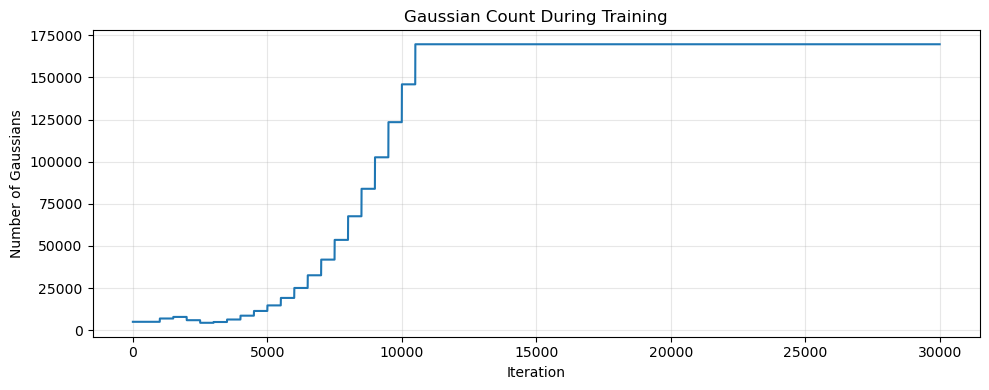

In [15]:
# ============================================================================
# Densification Analysis (optional)
# ============================================================================
# The DensificationController and train() with densification are now integrated 
# in the training cell above. This cell is for post-training analysis.
import matplotlib.pyplot as plt
if 'densify_log' in dir() and densify_log:
    print("Densification history:")
    for it, stats in densify_log:
        print(f"  iter {it+1}: N={stats['total_gaussians']} "
              f"(+{stats['cloned']} clone, +{stats['split']} split, "
              f"-{stats['pruned_amp']} amp, -{stats['pruned_scale']} scale)")
    
    # Plot Gaussian count over training
    if 'losses' in dir() and "N" in losses:
        plt.figure(figsize=(10, 4))
        plt.plot(losses["N"])
        plt.xlabel("Iteration")
        plt.ylabel("Number of Gaussians")
        plt.title("Gaussian Count During Training")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No densification log available. Run training with densify_enabled=True first.")

## 14) Save checkpoint

In [16]:
# # Clear GPU memory before training
# gc.collect()
# torch.cuda.empty_cache()

# # Reinitialize model with fresh state
# init_means, init_amp = init_gaussians_from_neurite_map(coords_grid, V_t, M, N0)
# model = GaussianMixtureVolume(N0, init_means, init_amp).to(DEVICE)
# print("Model N:", model.N)

# # Train with smaller topology patch to avoid OOM
# losses, densify_log = train(
#     model, V_t, coords_grid, M,
#     steps=3000,
#     batch=2_000,
#     topo_patch=(8, 16, 16),  # Reduced from (16,32,32) to avoid OOM
#     topo_every=50,           # Less frequent topology loss
#     densify_enabled=True,
#     max_gaussians=8000       # Limit max Gaussians
# )

In [17]:

CKPT_PATH = "neurogs_codec_ckpt_with reg_with_dens_2.pt"

# Save full checkpoint with model, entropy models, and training config
config = {
    # Model parameters
    "N0": N0,
    "model_N": model.N,
    
    # Training hyperparameters
    "steps": 3000,
    "batch": 2_000,
    "lr": 5e-3,
    "kappa": 4.0,
    "lam": 0.001,
    "alpha": 0.01,
    "beta_sparse": 0.01,
    "beta_smooth": 0.005,
    "beta_overlap": 0.01,
    "topo_every": 20,
    "topo_patch": (8, 16, 16),
    
    # Densification parameters
    "densify_enabled": True,
    "densify_from_iter": 500,
    "densify_until_iter": 2500,
    "densify_every": 200,
    "grad_threshold": 0.0005,
    "min_amplitude": 0.002,
    "max_gaussians": 8000,
    
    # Data info
    "tif_path": TIF_PATH,
    "voxel_spacing": VOXEL_SPACING,
    "shape_zyx": tuple(V_t.shape),
}

torch.save({
    "model_state": model.state_dict(),
    "entropy_state": {
        "H_mu": H_mu.state_dict(),
        "H_logs": H_logs.state_dict(),
        "H_q": H_q.state_dict(),
        "H_a": H_a.state_dict(),
        "H_b": H_b.state_dict(),
    },
    "Q": Q.__dict__,
    "config": config,
    "losses": losses if 'losses' in dir() else None,
    "densify_log": densify_log if 'densify_log' in dir() else None,
}, CKPT_PATH)

print("Saved checkpoint:", CKPT_PATH)
print("\nConfig saved:")
for k, v in config.items():
    print(f"  {k}: {v}")


Saved checkpoint: neurogs_codec_ckpt_with reg_with_dens_2.pt

Config saved:
  N0: 5000
  model_N: 169681
  steps: 3000
  batch: 2000
  lr: 0.005
  kappa: 4.0
  lam: 0.001
  alpha: 0.01
  beta_sparse: 0.01
  beta_smooth: 0.005
  beta_overlap: 0.01
  topo_every: 20
  topo_patch: (8, 16, 16)
  densify_enabled: True
  densify_from_iter: 500
  densify_until_iter: 2500
  densify_every: 200
  grad_threshold: 0.0005
  min_amplitude: 0.002
  max_gaussians: 8000
  tif_path: ./10-2900-control-cell-05_cropped_corrected.tif
  voxel_spacing: (0.126, 0.126, 1.0)
  shape_zyx: (100, 647, 813)


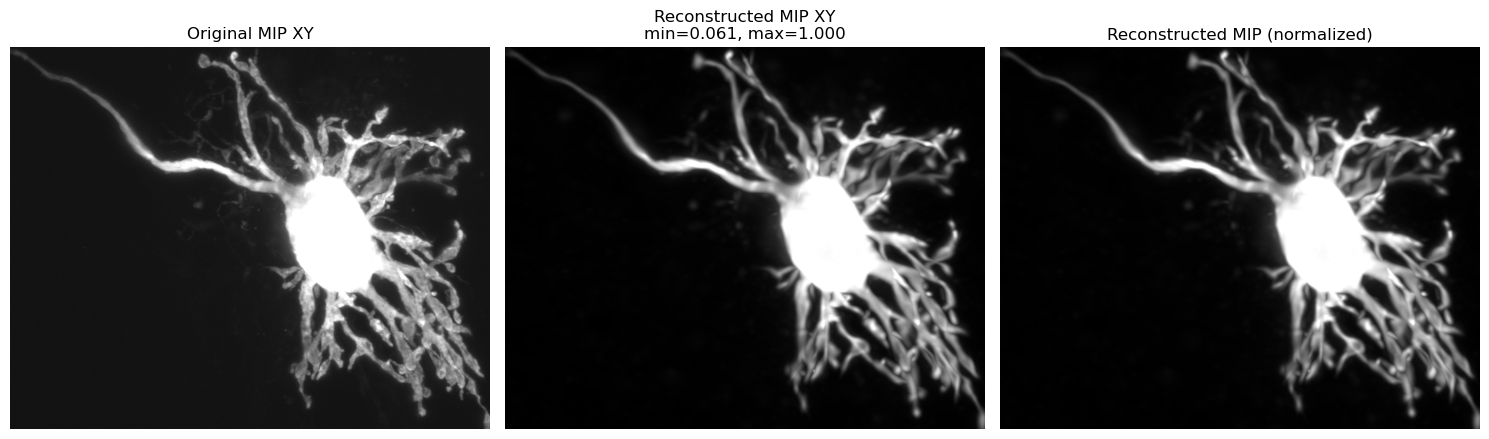

V_hat stats: min=0.0000, max=1.0000, mean=0.1021
V_t stats:   min=0.0000, max=1.0000, mean=0.1022


In [18]:

# show the mip projection of the reconstructed volume vs original
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original MIP
mip_orig = V_t.max(dim=0).values.cpu().numpy()
axes[0].imshow(mip_orig, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original MIP XY')
axes[0].axis('off')

# Reconstructed MIP (auto-scaled for visibility)
mip_recon = V_hat.max(dim=0).values.cpu().numpy()
axes[1].imshow(mip_recon, cmap='gray')  # auto-scale
axes[1].set_title(f'Reconstructed MIP XY\nmin={mip_recon.min():.3f}, max={mip_recon.max():.3f}')
axes[1].axis('off')

# Reconstructed MIP normalized to [0,1] for comparison
mip_recon_norm = (mip_recon - mip_recon.min()) / (mip_recon.max() - mip_recon.min() + 1e-8)
axes[2].imshow(mip_recon_norm, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Reconstructed MIP (normalized)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"V_hat stats: min={float(V_hat.min()):.4f}, max={float(V_hat.max()):.4f}, mean={float(V_hat.mean()):.4f}")
print(f"V_t stats:   min={float(V_t.min()):.4f}, max={float(V_t.max()):.4f}, mean={float(V_t.mean()):.4f}")
